In [6]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
df = pd.read_csv("StockData.csv")
df.drop(['Unnamed: 0'], axis=1, inplace = True)

In [8]:
df.head()

,Date,Open,High,Low,Close
0,2018-03-27,173.68,175.15,166.92,168.340
1,2018-03-26,168.07,173.10,166.44,172.770
2,2018-03-23,168.39,169.92,164.94,164.940
3,2018-03-22,170.00,172.68,168.60,168.845
4,2018-03-21,175.04,175.09,171.26,171.270


In [10]:
#data check
stock_data = df
# Convert the date column into a Datetime object:
stock_data['Date'] = pd.to_datetime(df.Date)
print(stock_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9400 entries, 0 to 9399
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9400 non-null   datetime64[ns]
 1   Open    9400 non-null   float64       
 2   High    9400 non-null   float64       
 3   Low     9400 non-null   float64       
 4   Close   9400 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 367.3 KB
None


In [ ]:
#By printing the first and last 5 elements, we can see that the data is in inverse order. The most recent data stored at the beginning of the set and the oldest data is at the end. For our model, we need to input the data from oldest to most recent. The Pandas method "sort_values" can be used to sort the data in chronological order.

In [11]:
stock_data=stock_data.sort_values(by='Date')
print(stock_data.head())

           Date   Open   High    Low  Close
9399 1980-12-12  28.75  28.87  28.75  28.75
9398 1980-12-15  27.38  27.38  27.25  27.25
9397 1980-12-16  25.37  25.37  25.25  25.25
9396 1980-12-17  25.87  26.00  25.87  25.87
9395 1980-12-18  26.63  26.75  26.63  26.63


In [20]:
# We extract only 4 columns (High, Low, Open, Close) from the full dataset to form a matrix
# where each ROW = one day, and each ROW contains 4 values [High, Low, Open, Close]
# These 4 values together form ONE single input vector fed into the LSTM at each time step
from sklearn.preprocessing import MinMaxScaler
price = stock_data[['High','Low','Open','Close']]
print(price[:5])

       High    Low   Open  Close
9399  28.87  28.75  28.75  28.75
9398  27.38  27.25  27.38  27.25
9397  25.37  25.25  25.37  25.25
9396  26.00  25.87  25.87  25.87
9395  26.75  26.63  26.63  26.63


In [21]:
#scaling ste^p:
scaler = MinMaxScaler(feature_range=(-1, 1))
price = scaler.fit_transform(price.values)
print(price[:5])

[[-0.94884358 -0.94844388 -0.94899391 -0.94863261]
 [-0.95313783 -0.95280073 -0.95295751 -0.95297352]
 [-0.95893076 -0.95860987 -0.95877273 -0.95876139]
 [-0.95711507 -0.95680904 -0.95732616 -0.95696715]
 [-0.95495353 -0.95460157 -0.95512737 -0.95476776]]


In [26]:
train_window=7 #Look at 7 days to predict the next
import numpy as np 
def create_in_out_sequences(price, tw):  # a function that return train and test sequences for the model 
    inout_seq=[]
    L=len(price)
    print("data length is :",L)
    for i in range(L-tw):
        data_seq=price[i:i+tw] #The 7 input prices
        data_label=price[i+tw:i+tw+1][0][3] #The price we want to predict
        inout_seq.append((data_seq,data_label)) #a list of tuples, where each tuple contains:(input_sequence, label)
    data=inout_seq
    print("number of sequences is :", len(data))
    #splitting the data into train and test 
    test_size=20 #the size of the test data is 20 sequences 
    train_size=len(data)-test_size
    print("the sizeof the training data is ",train_size)
    train=data[:train_size]
    test=data[train_size:]
    train= train[:-(tw-1)] #to avoid data leakage we removed the last 6 sequences because they contain the information of the 
    return train, test
train,test=create_in_out_sequences(price,train_window)


data length is : 9400
number of sequences is : 9393
the sizeof the training data is  9373


In [27]:
print(test[0])
print(train[-1])

(array([[-0.52820808, -0.53303223, -0.53350981, -0.53283172],
       [-0.52982203, -0.53404883, -0.53440669, -0.5345102 ],
       [-0.53022552, -0.5352397 , -0.53215004, -0.53676747],
       [-0.53071547, -0.5332065 , -0.53512997, -0.53233975],
       [-0.52581598, -0.52789114, -0.5297198 , -0.52378816],
       [-0.51503711, -0.52013593, -0.52196618, -0.51390537],
       [-0.51189567, -0.51447202, -0.51401004, -0.51558385]]), np.float64(-0.5163652148748373))
(array([[-0.56112112, -0.56992463, -0.56034371, -0.57013457],
       [-0.56803804, -0.58165473, -0.56843004, -0.58234698],
       [-0.57700122, -0.59556763, -0.57774595, -0.58046592],
       [-0.55970891, -0.5744514 , -0.57360876, -0.56096079],
       [-0.55723035, -0.56242648, -0.56362742, -0.55624367],
       [-0.54918942, -0.55885386, -0.56045943, -0.54747504],
       [-0.53319403, -0.54107789, -0.54094519, -0.53121111]]), np.float64(-0.5328317175517292))


In [28]:
class LSTM(nn.Module):
    def __init__(self, input_size=4, hidden_layer_size=100, output_size=1):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size

        self.lstm = nn.LSTM(input_size, hidden_layer_size)

        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, input_seq):
        hidden_cell = (torch.zeros(1,1,self.hidden_layer_size),
                       torch.zeros(1,1,self.hidden_layer_size),
                      )
        lstm_out, hidden_cell = self.lstm(input_seq.view(len(input_seq), 1, -1), hidden_cell)
        predictions = self.linear(lstm_out.view(len(input_seq), -1))
        return predictions[-1]

In [29]:
model=LSTM()
loss_function=nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [31]:
import sys
!{sys.executable} -m pip install tqdm --upgrade

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [ ]:
#Training the model 
from tqdm import tqdm #it shows the training progress
epochs = 5 #define the number of epochs 
for i in tqdm(range(epochs)): #loop over epochs but with progress bar 
    epoch_loss=0
    for seq,labels in tqdm(train):
        seq = torch.from_numpy(np.array(seq)).type(torch.FloatTensor)
        labels = torch.from_numpy(np.array(labels)).type(torch.FloatTensor)
        optimizer.zero_grad() #reset and clear previous gradients 
        y_pred = model(seq)
        labels = labels.view(1) #change the model output without changing its value
        single_loss = loss_function(y_pred, labels)
        single_loss.backward() #Compute gradients
        optimizer.step() #update weights 
        average_loss = epoch_loss / len(train)
        print(f'epoch: {i:3} loss: {average_loss:.10f}') #print the epoch result 


In [37]:
model.eval() #to put pytorch into evaluation mode
actual=[]
pred =[]
for seq, labels in test:
    seq = torch.from_numpy(np.array(seq)).type(torch.FloatTensor)
    labels = torch.from_numpy(np.array(labels)).type(torch.FloatTensor)
    actual.append(labels.item())
    with torch.no_grad():#disables gradient calculation because during evaluation we don't need the gradient
        pred.append(model(seq).item())
actual = np.array(actual)
pred = np.array(pred)

In [38]:
#convert the predicted and actual data into tensors
pred = torch.from_numpy(np.array(pred)).type(torch.Tensor)
actual = torch.from_numpy(np.array(actual)).type(torch.Tensor)

In [39]:
print(pred)
print(actual)

tensor([-0.5422, -0.5423, -0.5480, -0.5496, -0.5461, -0.5452, -0.5497, -0.5452,
        -0.5416, -0.5378, -0.5392, -0.5426, -0.5421, -0.5439, -0.5484, -0.5472,
        -0.5532, -0.5570, -0.5624, -0.5535])
tensor([-0.5164, -0.5254, -0.5219, -0.5201, -0.5206, -0.5253, -0.5198, -0.5110,
        -0.5059, -0.5110, -0.5154, -0.5148, -0.5167, -0.5245, -0.5247, -0.5362,
        -0.5432, -0.5545, -0.5318, -0.5447])


In [40]:
#convert the normalized values into thier scalar form. 
import numpy as np
pred_new = scaler.inverse_transform(np.c_[np.zeros(20),np.zeros(20),np.zeros(20),np.array(pred)])
print(pred_new[:,3])
actual_new = scaler.inverse_transform(np.c_[np.zeros(20),np.zeros(20),np.zeros(20),np.array(actual)])
print(actual_new[:,3])

[169.20660019 169.17210124 167.19756701 166.64764353 167.8402566
 168.16951042 166.61194999 168.16170439 169.39672542 170.69668685
 170.21514337 169.06434096 169.21069887 168.58881162 167.03909842
 167.45073777 165.38504393 164.07223035 162.20796916 165.29996027]
[178.11999474 174.99999256 176.21000958 176.81999212 176.67000924
 175.03000149 176.94000725 179.97999249 181.71999569 179.97000324
 178.44000078 178.65000152 178.0199993  175.2999995  175.24000223
 171.27000783 168.84501005 164.93999725 172.77000135 168.34000729]


C:\Users\nour\AppData\Local\Temp\ipykernel_8116\4274938331.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pred_new = scaler.inverse_transform(np.c_[np.zeros(20),np.zeros(20),np.zeros(20),np.array(pred)])
C:\Users\nour\AppData\Local\Temp\ipykernel_8116\4274938331.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  actual_new = scaler.inverse_transform(np.c_[np.zeros(20),np.zeros(20),np.zeros(20),np.array(actual)])


In [41]:
#model evaluation using mean squared error and mean absolute error 
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(actual_new, pred_new)
print("Mean Absolute Error (MAE):", mae)

rmse = np.sqrt(mean_squared_error(actual_new, pred_new))
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 1.9580030638724573
Root Mean Squared Error (RMSE): 4.190590798882804


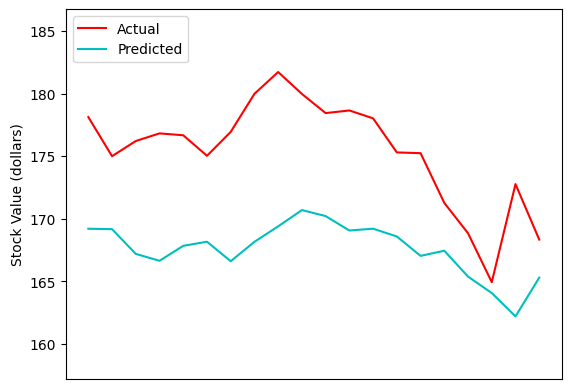

In [42]:
fig, ax = plt.subplots()

ax.plot(actual_new[:,3], 'r-', label='Actual')
ax.plot(pred_new[:,3], 'c-', label='Predicted')

ax.set_ylabel('Stock Value (dollars)')

ax.set_ylim(min(min(actual_new[:,3]), min(pred_new[:,3])) - 5, max(max(actual_new[:,3]), max(pred_new[:,3])) + 5)
plt.xticks([])

ax.legend(loc='upper left')

plt.show()